In [1]:
%matplotlib inline
import warnings
import time
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import brainstate
import braintools
import brainunit as u
import brainmass
from brainmass import objectives
from brainstate.nn import Param
brainstate.environ.set(dt=0.1 * u.ms)
brainstate.random.seed(0)


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Analyze Results (FC / FCD / spectra)

**Goal:** turn a simulated (or empirical) trajectory into the standard
whole-brain summaries — **functional connectivity (FC)**, **FC dynamics (FCD)**,
and **power spectra** — and visualize them.

`brainmass` does not reimplement these metrics: it surfaces
`braintools.metric` (`functional_connectivity`,
`functional_connectivity_dynamics`, `power_spectral_density`) and provides thin
`brainmass.viz` plotters on top. This recipe is the post-hoc analysis half of a
study; for fitting against these summaries see {doc}`/howto/custom_objective`.


## Produce a trajectory

We need a multi-region signal with real, *oscillatory* fluctuations so every
summary is non-trivial. A noisy Hopf `Network` near its bifurcation on the
bundled 8-region connectome gives spontaneous, correlated rhythms — the kind of
resting-state activity FC / FCD / spectra are designed for.


In [2]:
conn = brainmass.datasets.load_dataset('example_connectome')
W, D = conn.weights, conn.distances
N = W.shape[0]
labels = list(conn.labels)

node = brainmass.HopfStep(
    in_size=N, a=0.1, w=0.3,           # just past the oscillation onset
    noise_x=brainmass.OUProcess(N, sigma=0.1, tau=10 * u.ms),
)
brainstate.environ.set(dt=0.1 * u.ms)
net = brainmass.Network(node, conn=W, distance=D, speed=10 * u.mm / u.ms,
                        coupling='diffusive', coupled_var='x', k=0.5)

brainstate.random.seed(0)
res = brainmass.Simulator(net, dt=0.1 * u.ms).run(
    4000 * u.ms,
    monitors=lambda m: m.node.x.value,
    transient=400 * u.ms,
    sample_every=10,             # record every 1 ms
)
signal = res['output']           # (time, regions), unit-aware
print("trajectory:", signal.shape, "  std:", round(float(u.get_magnitude(signal).std()), 4))

trajectory: (3600, 8)   std: 0.0662


## Time series

Always eyeball the raw signal first. `brainmass.viz.plot_timeseries` strips units
and accepts the `'ts'` time axis directly.


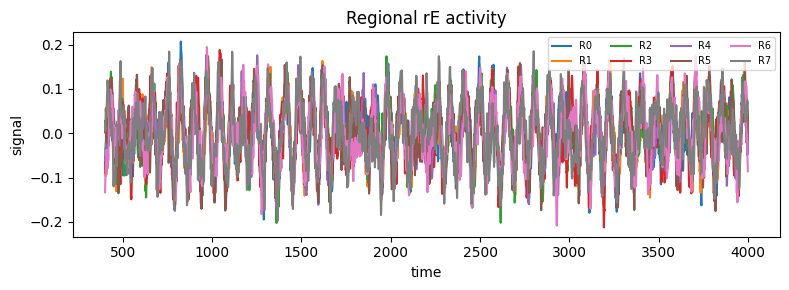

In [3]:
fig, ax = plt.subplots(figsize=(8, 3))
brainmass.viz.plot_timeseries(signal, ts=res['ts'], labels=labels, ax=ax)
ax.set_title('Regional rE activity')
ax.legend(fontsize=7, ncol=4, loc='upper right')
fig.tight_layout()
plt.show()

## Functional connectivity (FC)

FC is the matrix of pairwise correlations between region time series — the most
common static summary of coordinated activity. Compute it with
`braintools.metric.functional_connectivity` and plot it with
`brainmass.viz.plot_functional_connectivity` (which can also compute FC for you
from a time series — pass the raw signal, no `is_matrix`).


FC matrix: (8, 8)
mean off-diagonal FC: 0.677


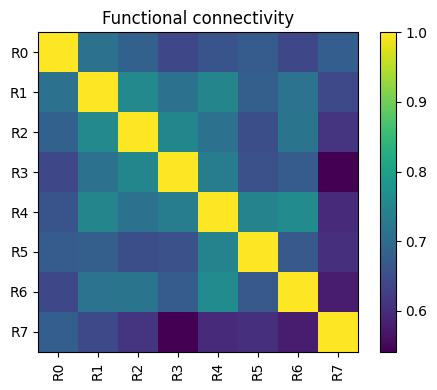

In [4]:
sig = u.get_magnitude(signal)
fc = braintools.metric.functional_connectivity(sig)
print("FC matrix:", fc.shape)

iu = np.triu_indices(N, 1)
print("mean off-diagonal FC:", round(float(fc[iu].mean()), 3))

fig, ax = plt.subplots(figsize=(5, 4))
brainmass.viz.plot_functional_connectivity(sig, labels=labels, ax=ax)
ax.set_title('Functional connectivity')
fig.tight_layout()
plt.show()

### Compare simulated FC to a target

The point of FC is usually comparison to empirical data. The bundled
`example_signal` ships a precomputed FC; score the match with an objective from
`brainmass.objectives` (which wraps `matrix_correlation`).


FC correlation (sim vs empirical): 0.573


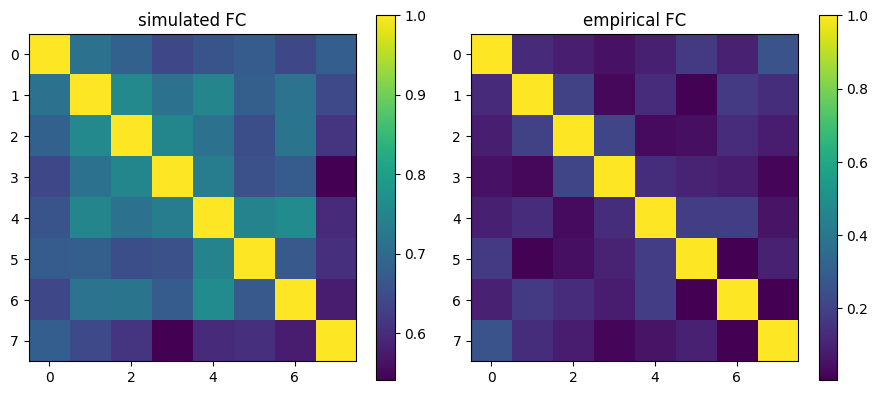

In [5]:
emp = brainmass.datasets.load_dataset('example_signal')
emp_fc = emp.fc                        # (8, 8) empirical FC
score = objectives.fc_corr()(sig, emp.signal)
print("FC correlation (sim vs empirical):", round(float(score), 3))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
brainmass.viz.plot_connectivity(fc, ax=axes[0]); axes[0].set_title('simulated FC')
brainmass.viz.plot_connectivity(emp_fc, ax=axes[1]); axes[1].set_title('empirical FC')
fig.tight_layout()
plt.show()

## FC dynamics (FCD)

FC computed over the whole run hides *non-stationarity*. **FCD** slides a window
along the signal, computes an FC per window, and correlates every pair of
windowed FCs — so the FCD matrix shows how connectivity itself drifts over time.
This surfaces `braintools.metric.functional_connectivity_dynamics` (the same
metric `brainmass.objectives.fcd` is built on).


FCD matrix: (176, 176) (n_windows, n_windows)


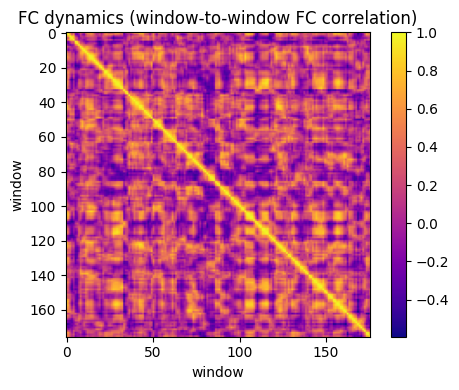

In [6]:
fcd = braintools.metric.functional_connectivity_dynamics(
    sig, window_size=100, step_size=20,   # samples (1 ms each here)
)
print("FCD matrix:", fcd.shape, "(n_windows, n_windows)")

fig, ax = plt.subplots(figsize=(5, 4))
brainmass.viz.plot_connectivity(fcd, ax=ax, cmap='plasma')
ax.set_title('FC dynamics (window-to-window FC correlation)')
ax.set_xlabel('window'); ax.set_ylabel('window')
fig.tight_layout()
plt.show()

The **distribution** of FCD off-diagonal values is the standard FCD fitting
target (a few stable states give a different distribution than a smoothly
drifting one). `brainmass.objectives.fcd_distribution` returns it as a smooth
density.


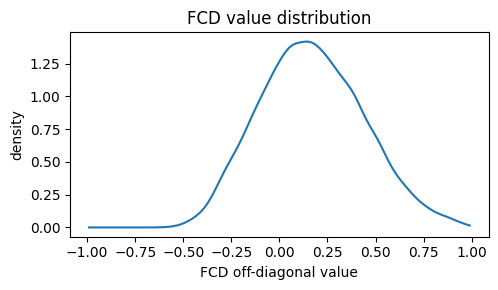

In [7]:
density = objectives.fcd_distribution(jnp.asarray(fcd))
midpoints = np.linspace(-0.99, 0.99, len(density))

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(midpoints, np.asarray(density))
ax.set_xlabel('FCD off-diagonal value')
ax.set_ylabel('density')
ax.set_title('FCD value distribution')
fig.tight_layout()
plt.show()

## Power spectra

The frequency content tells you which rhythms the model produces.
`brainmass.viz.plot_power_spectrum` surfaces
`braintools.metric.power_spectral_density` for a single region; the `dt` you pass
sets the frequency units (a `Quantity` is converted to ms).


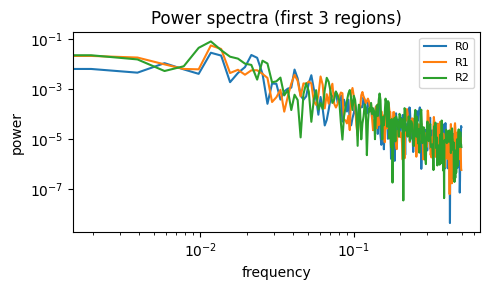

In [8]:
fig, ax = plt.subplots(figsize=(5, 3))
for r in range(3):
    brainmass.viz.plot_power_spectrum(sig[:, r], dt=res['ts'][1] - res['ts'][0],
                                      ax=ax, label=labels[r])
ax.set_title('Power spectra (first 3 regions)')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

For an aggregate view, average the per-region PSDs to get the network's mean
spectrum and read off the dominant frequency.


In [9]:
dt_ms = float((res['ts'][1] - res['ts'][0]).to(u.ms).mantissa)
freqs, psd0 = braintools.metric.power_spectral_density(sig[:, 0], dt_ms)
psds = np.stack([
    braintools.metric.power_spectral_density(sig[:, r], dt_ms)[1]
    for r in range(N)
])
mean_psd = psds.mean(axis=0)
peak_hz = float(np.asarray(freqs)[np.argmax(mean_psd)]) * 1e3   # cycles/ms -> Hz
print("dominant network frequency:", round(peak_hz, 1), "Hz")

dominant network frequency: 11.7 Hz


## Recap

| Summary | Metric (braintools) | Plotter (brainmass.viz) |
| --- | --- | --- |
| Time series | — | `plot_timeseries` |
| FC | `functional_connectivity` | `plot_functional_connectivity` |
| FCD | `functional_connectivity_dynamics` | `plot_connectivity` |
| Spectrum | `power_spectral_density` | `plot_power_spectrum` |

These are exactly the quantities the `brainmass.objectives` builders score
against, so the analysis you run here is the loss you would fit in
{doc}`/tutorials/06_fitting_with_gradients`.

## Next steps

- {doc}`/howto/custom_objective` — fit a model to these summaries.
- {doc}`/howto/parameter_sweeps` — sweep parameters and watch FC change.
- {doc}`/tutorials/05_forward_models` — map activity to BOLD / EEG / MEG first.
- {doc}`/reference/viz` — the full visualization API.
